In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [ ]:
# Clone the repository
!git clone https://github.com/JeremyIV/diffc.git
%cd diffc

# Install dependencies into the default conda environment
!conda env update -n base -f environment.yml

# Install the Hugging Face datasets library
!pip install datasets huggingface_hub

Cloning into 'diffc'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 249 (delta 110), reused 232 (delta 96), pack-reused 0 (from 0)
Receiving objects: 100% (249/249), 22.44 MiB | 18.53 MiB/s, done.
Resolving deltas: 100% (110/110), done.
/content/diffc
Channels:
 - pytorch
 - nvidia
 - conda-forge
Platform: linux-64
Solving environment: | failed

SpecsConfigurationConflictError: Requested specs conflict with configured specs.
  requested specs: 
    - cupy
    - pip
    - python=3.8
    - pytorch
    - rust
    - torchaudio
    - torchvision
  pinned specs: 
    - cuda-version=12
    - python=3.12
    - python_abi=3.12[build=*cp312*]
Use 'conda config --show-sources' to look for 'pinned_specs' and 'track_features'
configuration parameters.  Pinned specs may also be defined in the file
/usr/local/conda-meta/pinned.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 25.

In [ ]:
import os
from tqdm import tqdm
from datasets import load_dataset
from huggingface_hub import login

# Authenticate with Hugging Face
HF_TOKEN = "HF_TOKEN"  # Paste your token here
login(token=HF_TOKEN)

# Stream validation split
dataset = load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True)

# Define the target directory inside the cloned repo structure
output_dir = "data/imagenet_subset"
os.makedirs(output_dir, exist_ok=True)

print("Streaming and saving 100 validation images...")
count = 0
max_images = 100

for item in tqdm(dataset, total=max_images):
    img = item['image'].convert('RGB')
    img.save(os.path.join(output_dir, f"img_{count:04d}.png"))
    count += 1
    if count >= max_images:
        break

print(f"Successfully saved {count} images to {output_dir}")

README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Streaming and saving 100 validation images...


 99%|█████████▉| 99/100 [00:16<00:00,  6.15it/s]

Successfully saved 100 images to data/imagenet_subset


In [ ]:
!conda run -n base pip install pillow torchvision datasets diffusers transformers accelerate torch scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.2/532.2 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 148.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!conda run -n base pip install cupy-cuda12x omegaconf einops lpips piq

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.0/134.0 MB 56.8 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144555 sha256=3d46167a1e69a1c581c8c1171c4163f58f7c5596397aeb64ee667cc01f6794d9
  Stored in directory: /root/.cache/pip/wheels/1a/97/32/461f837398029ad76911109f07047fde1d7b661a147c7c56d1
Successfully built antlr4-python3-runtime



In [ ]:
# Install rust/cargo via conda and maturin via pip in base
!conda install -n base -y -c conda-forge rust
!conda run -n base pip install maturin

Channels:
 - conda-forge
Platform: linux-64
Solving environment: | / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - rust


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    binutils_impl_linux-64-2.43|       h4bf12b8_2         5.4 MB  conda-forge
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    gcc_impl_linux-64-14.2.0   |       hdb7739f_2        70.1 MB  conda-forge
    kernel-headers_linux-64-5.14.0|       he073ed8_3         1.3 MB  conda-forge
    libgcc-devel_linux-64-14.2.0|     h9c4974d_102         2.6 MB  conda-forge
    libsanitizer-14.2.0        |       hed042b8_2         4.3 MB  conda-forge
    libzlib-1.3.2              |       h25fd6f3_2  

In [ ]:
import os
import subprocess

# Search for the zipf_encoding folder containing Cargo.toml
target_dir = None
for root, dirs, files in os.walk("/content/diffc"):
    if "Cargo.toml" in files:
        with open(os.path.join(root, "Cargo.toml"), "r") as f:
            if "zipf" in f.read():
                target_dir = root
                break

if target_dir:
    print(f"Found zipf_encoding directory at: {target_dir}")
    print("Compiling and installing the Rust extension...")
    # Compile the extension inside the base environment
    result = subprocess.run(
        ["conda", "run", "-n", "base", "pip", "install", target_dir],
        capture_output=True,
        text=True
    )
    if result.returncode == 0:
        print("Success: Compilation and installation completed!")
    else:
        print("Compilation failed. Error output below:")
        print(result.stderr)
else:
    print("Could not locate a Cargo.toml for zipf_encoding. Current directory structure:")
    # Fallback to list files if the search fails
    !find /content/diffc -name "*zipf*"

Found zipf_encoding directory at: /content/diffc/lib/diffc/rcc/arithmetic-coding/python-bindings
Compiling and installing the Rust extension...
Success: Compilation and installation completed!


In [ ]:
!conda run -n base pip install easydict scikit-image imageio matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00



In [ ]:
import os
import shutil

# Paths to check
src_path = "/content/data/imagenet_subset"
dst_path = "/content/diffc/data/imagenet_subset"

# Count images in each folder
src_count = len(os.listdir(src_path)) if os.path.exists(src_path) else 0
dst_count = len(os.listdir(dst_path)) if os.path.exists(dst_path) else 0

print(f"Images found in default Colab directory: {src_count}")
print(f"Images found in repository directory: {dst_count}")

# If they are in the wrong place, move them automatically
if src_count > 0:
    os.makedirs(dst_path, exist_ok=True)
    for filename in os.listdir(src_path):
        shutil.move(os.path.join(src_path, filename), os.path.join(dst_path, filename))
    print(f"\nMoved {src_count} images to the repository directory: {dst_path}")
elif dst_count > 0:
    print("\nImages are already in the correct directory.")
else:
    print("\nNo images were found in either folder. Please check if your Hugging Face download step ran successfully.")

Images found in default Colab directory: 100
Images found in repository directory: 0

Moved 100 images to the repository directory: /content/diffc/data/imagenet_subset


In [ ]:
import os
from PIL import Image

image_dir = "/content/diffc/data/imagenet_subset"
files = [f for f in os.listdir(image_dir) if f.endswith(".png")]

print(f"Resizing {len(files)} images to 512x512...")
for f in files:
    path = os.path.join(image_dir, f)
    img = Image.open(path).convert("RGB")

    # Crop to square (center crop)
    width, height = img.size
    min_dim = min(width, height)
    left = (width - min_dim) / 2
    top = (height - min_dim) / 2
    right = (width + min_dim) / 2
    bottom = (height + min_dim) / 2
    img_cropped = img.crop((left, top, right, bottom))

    # Resize to 512x512
    img_resized = img_cropped.resize((512, 512), Image.Resampling.LANCZOS)
    img_resized.save(path)

print("Preprocessing complete! All images are now standard 512x512.")

Resizing 100 images to 512x512...
Preprocessing complete! All images are now standard 512x512.


In [ ]:
!rm -rf /content/diffc/results/SD-1.5-base/imagenet_subset

In [ ]:
!conda run -n base pip install pytest

In [ ]:
%cd /content/diffc
!conda run -n base python evaluate.py --config configs/SD-1.5-base.yaml --image_dir data/imagenet_subset --output_dir results/SD-1.5-base/imagenet_subset

Streaming output truncated to the last 5000 lines.
100%|██████████| 17/17 [00:01<00:00,  9.93it/s]

100%|██████████| 12/12 [00:01<00:00, 10.01it/s]

100%|██████████| 7/7 [00:00<00:00, 10.01it/s]

100%|██████████| 7/7 [00:00<00:00, 10.04it/s]

100%|██████████| 6/6 [00:00<00:00, 10.03it/s]

100%|██████████| 6/6 [00:00<00:00, 10.07it/s]

100%|██████████| 5/5 [00:00<00:00, 10.18it/s]

100%|██████████| 5/5 [00:00<00:00, 10.17it/s]

100%|██████████| 4/4 [00:00<00:00, 10.19it/s]

100%|██████████| 4/4 [00:00<00:00, 10.23it/s]

100%|██████████| 3/3 [00:00<00:00, 10.44it/s]

100%|██████████| 2/2 [00:00<00:00, 10.50it/s]

100%|██████████| 161/161 [00:29<00:00,  5.47it/s]

100%|██████████| 47/47 [00:04<00:00,  9.72it/s]

100%|██████████| 41/41 [00:04<00:00,  9.79it/s]

100%|██████████| 37/37 [00:03<00:00,  9.79it/s]

100%|██████████| 32/32 [00:03<00:00,  9.85it/s]

100%|██████████| 27/27 [00:02<00:00,  9.87it/s]

100%|██████████| 22/22 [00:02<00:00,  9.89it/s]

100%|██████████| 17/17 [00:01<00:00,

In [ ]:
import pandas as pd

csv_path = "/content/diffc/results/SD-1.5-base/imagenet_subset/results.csv"
df = pd.read_csv(csv_path)

# 1. Print a preview of the raw columns and data
print("--- CSV Data Preview ---")
print(f"Total rows generated: {len(df)}")
print("Columns in CSV:", df.columns.tolist())
print(df.head(3))

# 2. Identify the column used for the different quality steps
step_col = None
for col in df.columns:
    if any(k in col.lower() for k in ['step', 'time', 'recon_t', 'quality']) or col.lower() == 't':
        step_col = col
        break

# 3. Print the grouped Rate-Distortion averages
print("\n--- FINAL RATE-DISTORTION CURVE SUMMARY (Averages) ---")
if step_col:
    # Group by the timestep to show the average bpp, PSNR, MS-SSIM, and LPIPS per quality point
    summary = df.groupby(step_col).mean(numeric_only=True)
    # Sort from lowest step (highest compression) to highest step (highest quality)
    summary = summary.sort_index()
    print(summary)
else:
    print("Could not automatically group by step. Showing overall average across all runs:")
    print(df.mean(numeric_only=True))

--- CSV Data Preview ---
Total rows generated: 1800
Columns in CSV: ['Unnamed: 0', 'gt_path', 'recon_path', 'recon_step_idx', 'recon_timestep', 'snr', 'bpp', 'psnr', 'lpips']
   Unnamed: 0                            gt_path  \
0           0  data/imagenet_subset/img_0075.png   
1           1  data/imagenet_subset/img_0075.png   
2           2  data/imagenet_subset/img_0075.png   

                                          recon_path  recon_step_idx  \
0  results/SD-1.5-base/imagenet_subset/897/img_00...               3   
1  results/SD-1.5-base/imagenet_subset/780/img_00...               7   
2  results/SD-1.5-base/imagenet_subset/688/img_00...              11   

   recon_timestep       snr       bpp       psnr     lpips  
0             897  0.122352  0.001648  10.673192  0.758189  
1             780  0.215045  0.002350  13.534883  0.704995  
2             688  0.315786  0.003448  15.848699  0.552616  

--- FINAL RATE-DISTORTION CURVE SUMMARY (Averages) ---
                Unnamed: 0 

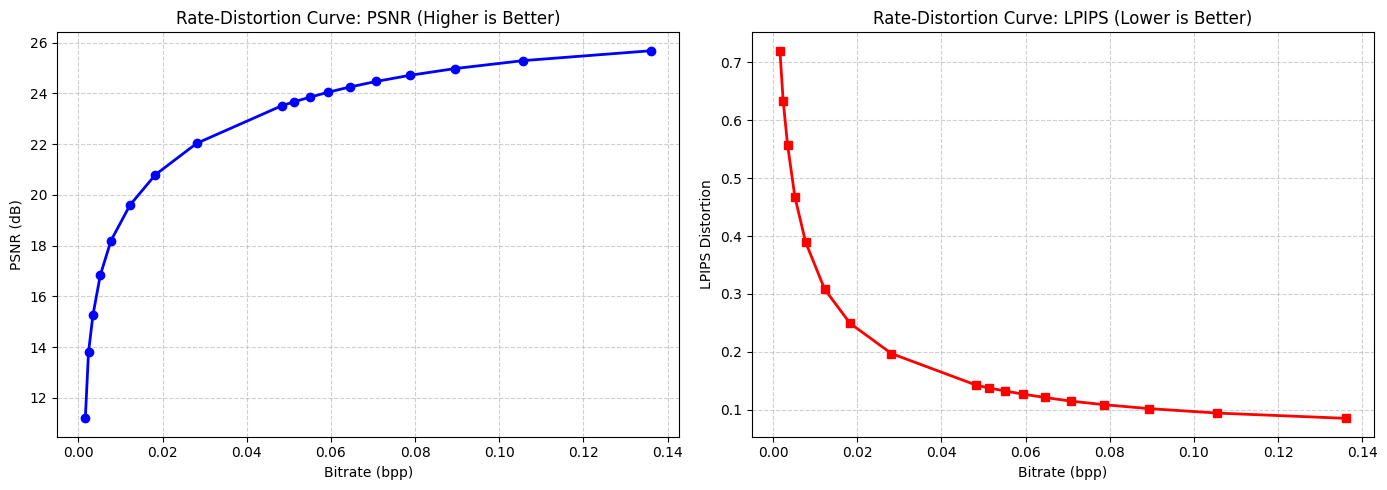

Plots generated and saved to: /content/diffc/results/SD-1.5-base/imagenet_subset/rd_curves.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data and compute the grouped averages
csv_path = "/content/diffc/results/SD-1.5-base/imagenet_subset/results.csv"
df = pd.read_csv(csv_path)
summary = df.groupby('recon_timestep').mean(numeric_only=True).sort_index()

# Plotting setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: bpp vs PSNR (Higher is better)
ax1.plot(summary['bpp'], summary['psnr'], marker='o', color='blue', linewidth=2)
ax1.set_title("Rate-Distortion Curve: PSNR (Higher is Better)")
ax1.set_xlabel("Bitrate (bpp)")
ax1.set_ylabel("PSNR (dB)")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: bpp vs LPIPS (Lower is better)
ax2.plot(summary['bpp'], summary['lpips'], marker='s', color='red', linewidth=2)
ax2.set_title("Rate-Distortion Curve: LPIPS (Lower is Better)")
ax2.set_xlabel("Bitrate (bpp)")
ax2.set_ylabel("LPIPS Distortion")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("/content/diffc/results/SD-1.5-base/imagenet_subset/rd_curves.png", dpi=300)
plt.show()

print("Plots generated and saved to: /content/diffc/results/SD-1.5-base/imagenet_subset/rd_curves.png")

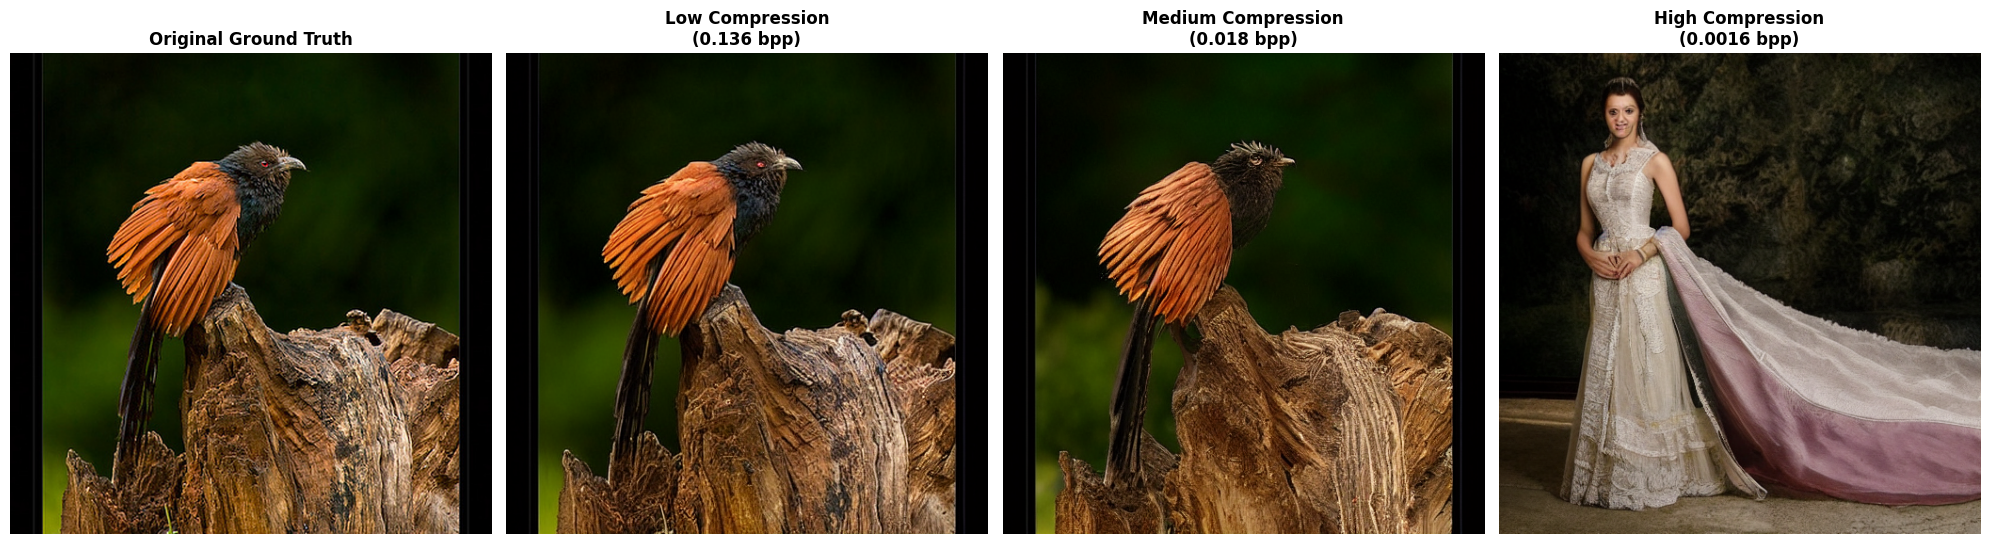

Visual comparison grid saved to: /content/diffc/results/SD-1.5-base/imagenet_subset/visual_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Select an image index to display (using 'img_0000.png' as a default)
image_filename = "img_0000.png"

gt_path = f"/content/diffc/data/imagenet_subset/{image_filename}"

# Map specific timesteps to their respective visual quality levels
recons = {
    "Original Ground Truth": gt_path,
    "Low Compression\n(0.136 bpp)": f"/content/diffc/results/SD-1.5-base/imagenet_subset/010/{image_filename}",
    "Medium Compression\n(0.018 bpp)": f"/content/diffc/results/SD-1.5-base/imagenet_subset/296/{image_filename}",
    "High Compression\n(0.0016 bpp)": f"/content/diffc/results/SD-1.5-base/imagenet_subset/897/{image_filename}"
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, (title, path) in enumerate(recons.items()):
    if os.path.exists(path):
        img = Image.open(path)
        axes[i].imshow(img)
        axes[i].set_title(title, fontsize=12, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"Image not found:\n{os.path.basename(path)}",
                     ha='center', va='center', color='red')
        axes[i].axis('off')

plt.tight_layout()
plt.savefig("/content/diffc/results/SD-1.5-base/imagenet_subset/visual_comparison.png", dpi=300)
plt.show()

print("Visual comparison grid saved to: /content/diffc/results/SD-1.5-base/imagenet_subset/visual_comparison.png")

In [ ]:
import shutil

# 1. Compress the folder into a zip file
shutil.make_archive('diffcZ', 'zip', '/content/diffc')


'/content/diffc/diffcZ.zip'